# Lab Manual 4 
**Roll Number:** 24i-2558 
**Name:** Nauman Rafay


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('Sample_-_Superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df.shape)
df.head()

(9994, 23)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Profitable
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11,Profit > 0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11,Profit > 0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06,Profit > 0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10,Profit <= 0
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10,Profit > 0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## Task 1 

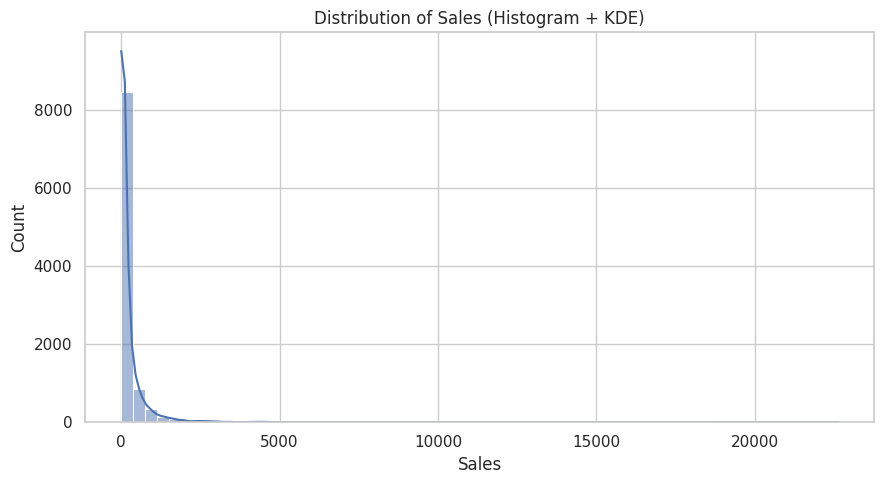

Skewness of Sales: 12.973
Mean:   229.86
Median: 54.49


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['Sales'], kde=True, bins=60, ax=ax, color='#4C72B0')
ax.set_title('Distribution of Sales (Histogram + KDE)')
ax.set_xlabel('Sales')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

sales_skew = df['Sales'].skew()
sales_mean = df['Sales'].mean()
sales_median = df['Sales'].median()

print(f"Skewness of Sales: {sales_skew:.3f}")
print(f"Mean:   {sales_mean:.2f}")
print(f"Median: {sales_median:.2f}")

Interpretation: The skewness value is well above 0, and the
mean  sits far above the median, right-skewed.
Sales is therefore not symmetric; a small number of high-value orders pull the mean upward,
so the mean overstates a "typical" order and the median is a more representative summary for
this column.

## Task 2 

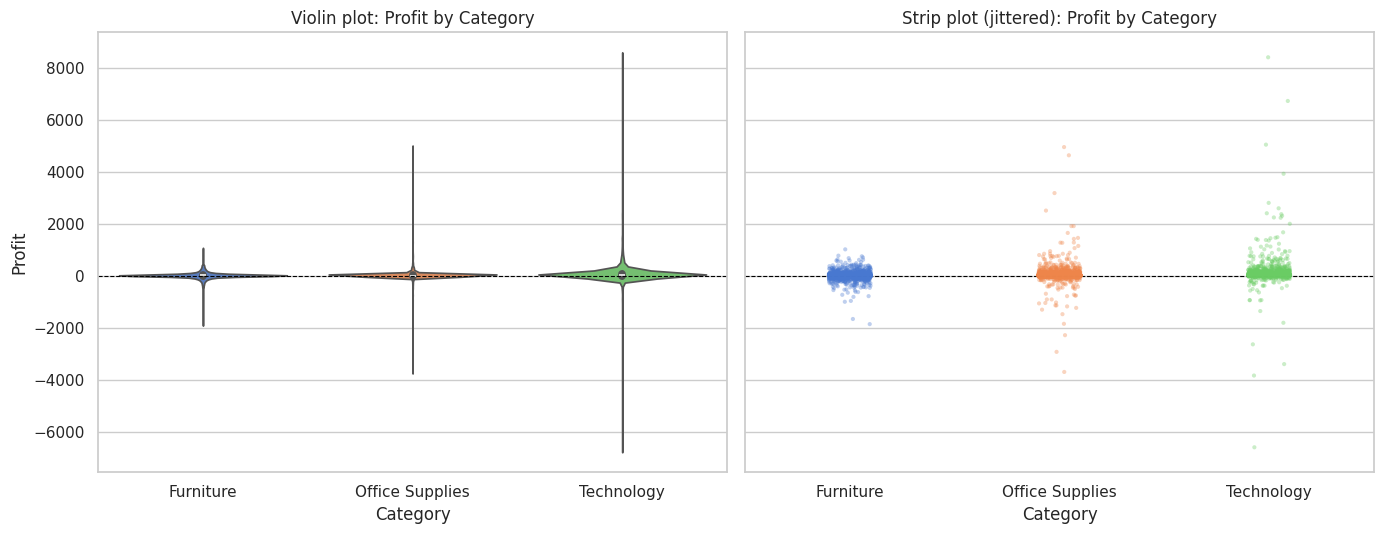

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

sns.violinplot(data=df, x='Category', y='Profit', ax=axes[0], hue='Category',
               palette='muted', legend=False)
axes[0].set_title('Violin plot: Profit by Category')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

sns.stripplot(data=df, x='Category', y='Profit', ax=axes[1], jitter=True,
              alpha=0.35, size=3, hue='Category', palette='muted', legend=False)
axes[1].set_title('Strip plot (jittered): Profit by Category')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

Interpretation: The violin plot better reveals category-level distribution shape,
it shows that Furniture have a dense, sharply-peaked mass near zero with long
thin tails in both directions, which is easy to read.
The strip plot is more useful for spotting exact outliers and the true sample size per category,
but with 10k points it overlaps too much to judge bimodality reliably, the violin's estimated
density does that job better here.

## Task 3 

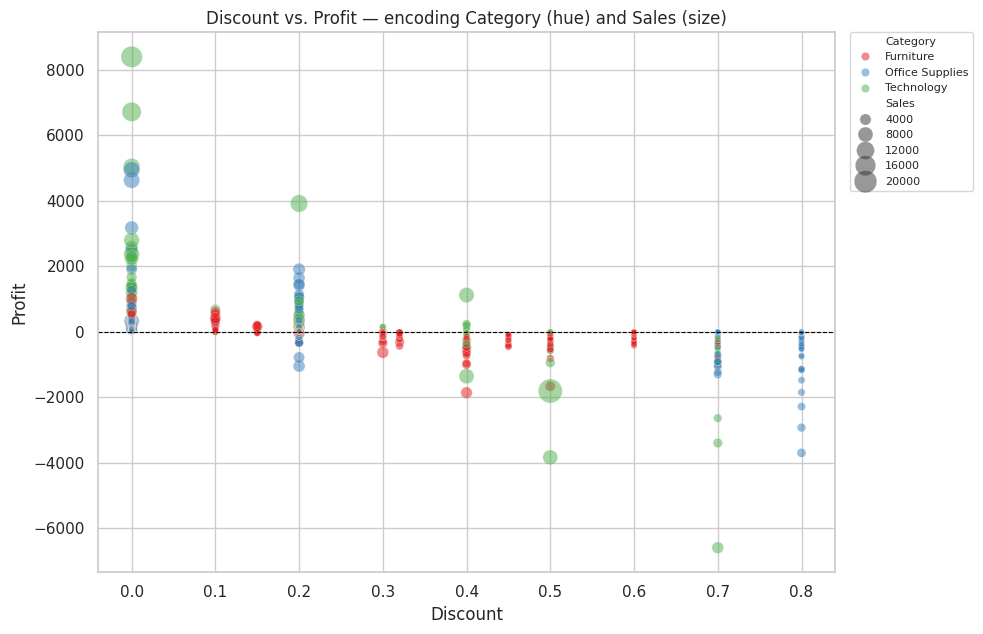

In [5]:
fig, ax = plt.subplots(figsize=(10, 6.5))
scatter = sns.scatterplot(
    data=df, x='Discount', y='Profit', hue='Category', size='Sales',
    sizes=(15, 300), alpha=0.5, palette='Set1', ax=ax
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Discount vs. Profit — encoding Category (hue) and Sales (size)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

Pattern only visible with 4 variables: the largest-size points (highest `Sales`) that
still land in deep-loss territory are concentrated at high discount levels and are
disproportionately Technology/Furniture, i.e. it is specifically the big-ticket
orders in these categories that get heavily discounted that produce the largest losses, a
pattern that a plain 2-variable discount-vs-profit scatter cannot show since it hides which
category and which order size is driving those losses.

## Task 4 

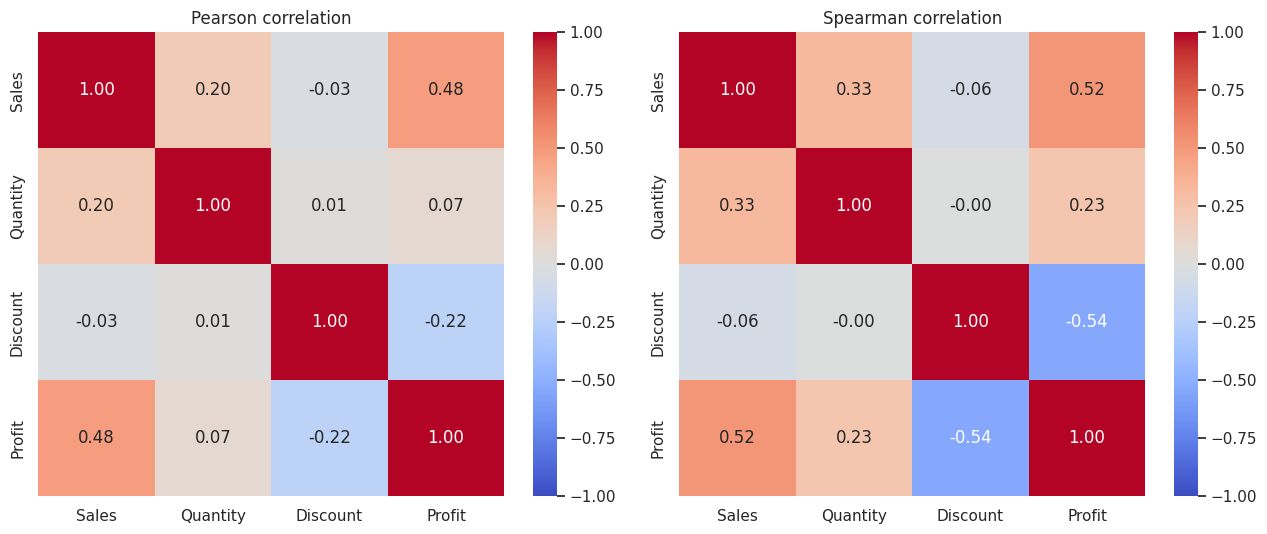

Pair with the largest |Pearson - Spearman| gap: ('Discount', 'Profit')
Pearson : -0.21948745637176792
Spearman: -0.5433501822306211


In [6]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson correlation')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman correlation')
plt.tight_layout()
plt.show()

diff = (pearson_corr - spearman_corr).abs().copy()
vals = diff.values.copy()
np.fill_diagonal(vals, 0)
diff = pd.DataFrame(vals, index=diff.index, columns=diff.columns)
pair = diff.stack().idxmax()
print('Pair with the largest |Pearson - Spearman| gap:', pair)
print('Pearson :', pearson_corr.loc[pair[0], pair[1]])
print('Spearman:', spearman_corr.loc[pair[0], pair[1]])

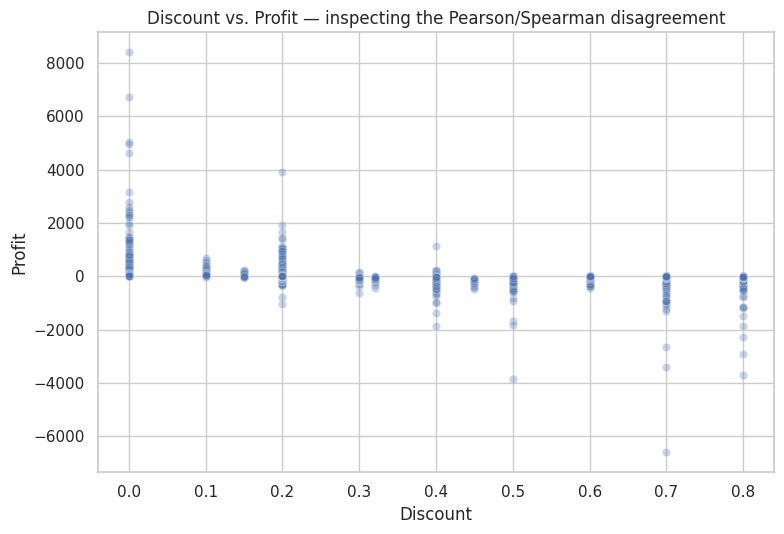

In [7]:
col_a, col_b = pair
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=df, x=col_a, y=col_b, alpha=0.3, ax=ax)
ax.set_title(f'{col_a} vs. {col_b} — inspecting the Pearson/Spearman disagreement')
plt.tight_layout()
plt.show()

Explanation of the disagreement: Discount and Profit show the largest gap between
the two coefficients. Pearson is pulled down by a handful of extreme-loss outliers at high
discount levels and by the relationship being non-linear (profit collapses sharply only past a
discount threshold rather than falling steadily), while Spearman, being rank-based,is far
less sensitive to those extreme values and instead captures the more general monotonic tendency more robustly.

Correlation != causation: even where a real relationship shows up here (e.g., discount and
profit), the correlation coefficient alone cannot prove that discounting causes lower profit,
it may be confounded by which categories/regions get discounted, order size, or other unobserved
factors, and should not be read as a causal claim without further analysis.

## Task 5

In [8]:
pivot_sales = pd.pivot_table(
    df, index='Region', columns='Category', values='Sales',
    aggfunc='sum', margins=True
)
pivot_sales_display = pivot_sales.round(0)
pivot_sales_display

Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,163797.0,167026.0,170416.0,501240.0
East,208291.0,205516.0,264974.0,678781.0
South,117299.0,125651.0,148772.0,391722.0
West,252613.0,220853.0,251992.0,725458.0
All,742000.0,719047.0,836154.0,2297201.0


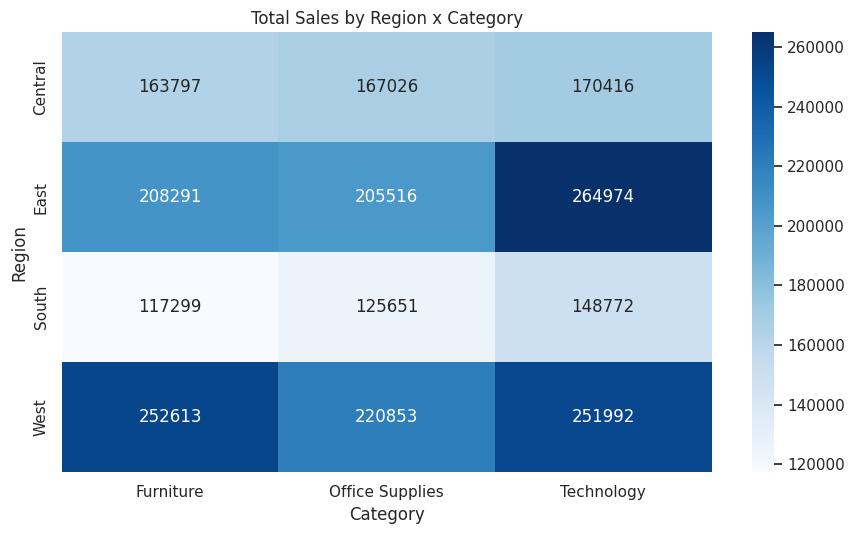

Top region-category combination: ('East', 'Technology') -> total sales = 264,974


In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(pivot_sales.drop(index='All', columns='All'), annot=True, fmt='.0f',
            cmap='Blues', ax=ax)
ax.set_title('Total Sales by Region x Category')
plt.tight_layout()
plt.show()

top_cell = pivot_sales.drop(index='All', columns='All').stack().idxmax()
top_value = pivot_sales.drop(index='All', columns='All').stack().max()
print(f"Top region-category combination: {top_cell} -> total sales = {top_value:,.0f}")

**Interpretation:** the printed top combination is the single largest contributor to
overall revenue, and the `margins=True` row/column totals make it easy to sanity-check that
combination's share against each region's and each category's grand total before charting.

## Task 6

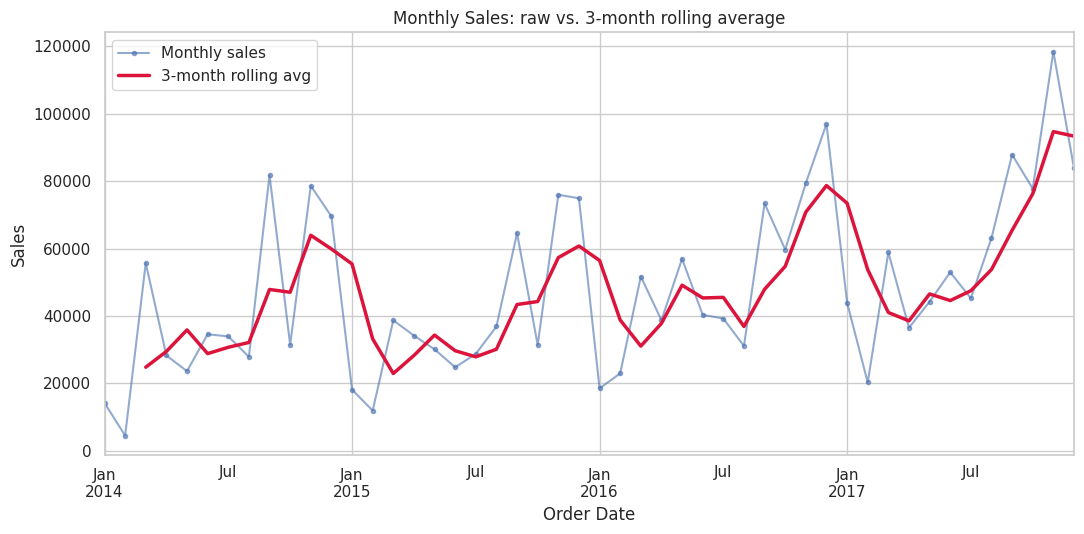

In [10]:
ts = df.set_index('Order Date').sort_index()
monthly = ts['Sales'].resample('ME').sum()
rolling = monthly.rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(11, 5.5))
monthly.plot(ax=ax, label='Monthly sales', marker='o', markersize=3, alpha=0.6)
rolling.plot(ax=ax, label='3-month rolling avg', linewidth=2.5, color='crimson')
ax.set_title('Monthly Sales: raw vs. 3-month rolling average')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** the raw monthly line jumps sharply month-to-month (short-term noise,
partly seasonal spikes), which makes any longer-run direction hard to judge by eye. The
3-month rolling average smooths those spikes out and reveals the **underlying upward trend**
in sales across the period much more clearly than the raw series alone.

## Task 7

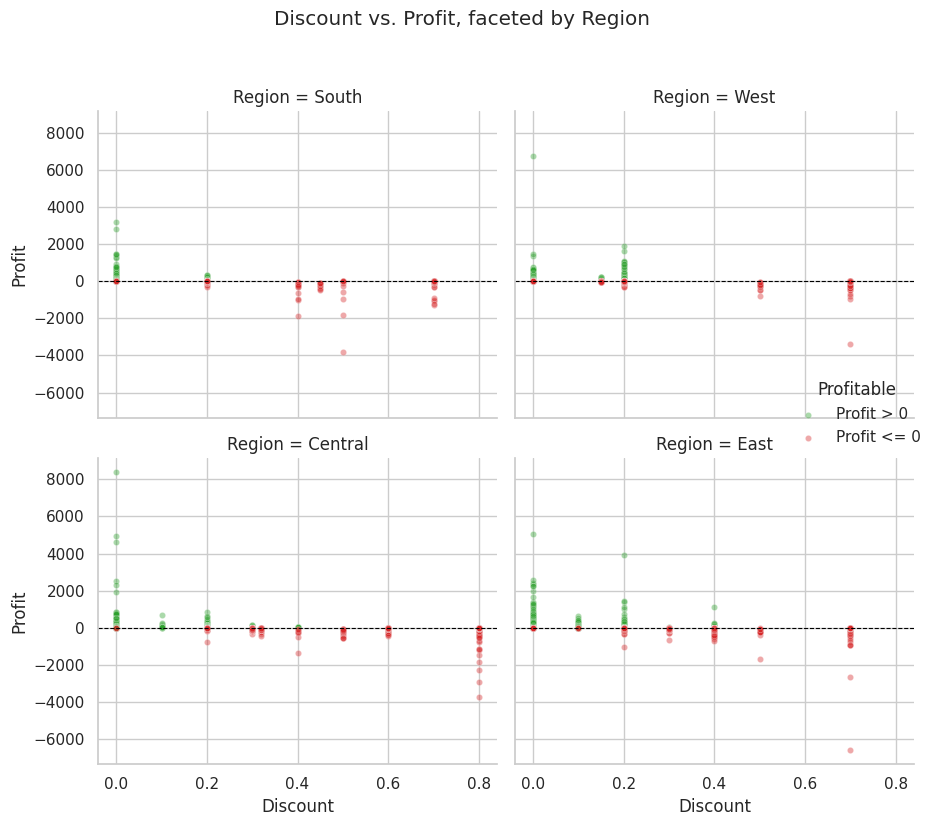

In [11]:
df['Profitable'] = np.where(df['Profit'] > 0, 'Profit > 0', 'Profit <= 0')

g = sns.FacetGrid(df, col='Region', hue='Profitable', col_wrap=2, height=4,
                   palette={'Profit > 0': '#2ca02c', 'Profit <= 0': '#d62728'})
g.map(sns.scatterplot, 'Discount', 'Profit', alpha=0.4, s=20)
for ax in g.axes.flat:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
g.add_legend()
g.fig.suptitle('Discount vs. Profit, faceted by Region', y=1.03)
plt.tight_layout()
plt.show()

**Interpretation:** the **Central** region visibly differs from the others a much larger
share of its points sit below the profit = 0 line (about 32% of Central orders are loss-making,
versus roughly 10-19% in West/South/East), so the red (unprofitable) cluster is noticeably denser
across the whole discount range in Central than in any other region, not just at high discounts.

## Task 8

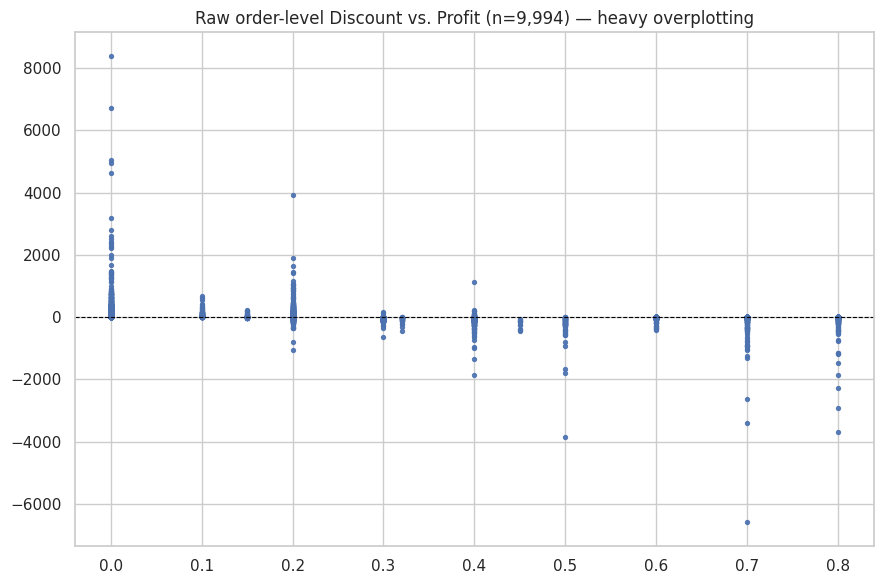

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['Discount'], df['Profit'], s=8, alpha=0.9)
ax.set_title(f'Raw order-level Discount vs. Profit (n={len(df):,}) — heavy overplotting')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

Number of order-level points: 9,994


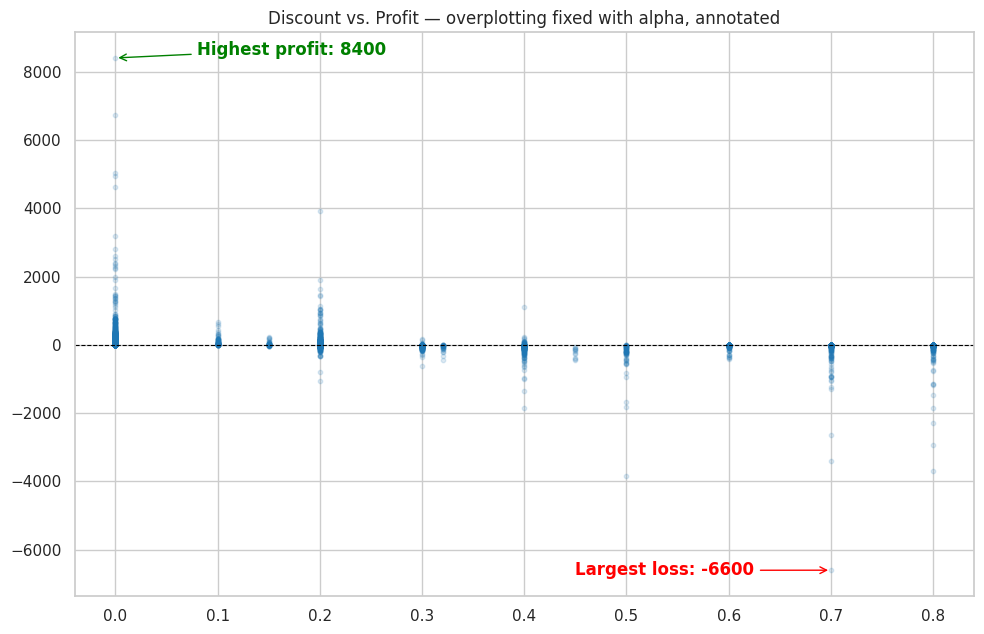

In [13]:
n_points = len(df)
print(f"Number of order-level points: {n_points:,}")

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(df['Discount'], df['Profit'], s=10, alpha=0.15, color='#1f77b4')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

best = df.loc[df['Profit'].idxmax()]
worst = df.loc[df['Profit'].idxmin()]

ax.annotate(f"Highest profit: {best['Profit']:.0f}",
            xy=(best['Discount'], best['Profit']),
            xytext=(best['Discount'] + 0.08, best['Profit'] + 100),
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontweight='bold')

ax.annotate(f"Largest loss: {worst['Profit']:.0f}",
            xy=(worst['Discount'], worst['Profit']),
            xytext=(worst['Discount'] - 0.25, worst['Profit'] - 150),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontweight='bold')

ax.set_title('Discount vs. Profit — overplotting fixed with alpha, annotated')
plt.tight_layout()
plt.show()

Choice of fix: with ~10k points, **alpha
transparency** is the appropriate fix rather than hexbin/KDE, it keeps individual extreme points visible while letting dense regions read as darker, whereas
hexbinning would obscure exactly the single most-profitable/least-profitable orders we need to
annotate.

The plot above marks the single most profitable order and the single largest loss directly on
the de-cluttered scatter.

## Save cleaned dataset for submission

In [14]:
df.to_csv('Sample_-_Superstore_cleaned.csv', index=False)
print('Cleaned dataset saved:', 'Sample_-_Superstore_cleaned.csv')

Cleaned dataset saved: Sample_-_Superstore_cleaned.csv
